In [1]:
%load_ext autoreload
%autoreload 2

## Data curation

Curating raw data with the enhanced chat client

In [2]:
import os

import dotenv

dotenv.load_dotenv()

DATA_DIR = os.getenv("DATA_DIR")

In [3]:
import glob
import json
import os

import pandas as pd

if os.path.exists("../../data/curation_v1/perturbations/all_context_perturbations_structured.csv"):
    df = pd.read_csv("../../data/curation_v1/perturbations/all_context_perturbations_structured.csv")
else:
    all_data = []
    data_dir = "../../data/curation_v1/perturbations/all_context_perturbations_structured/"

    # Load all perturbation batch files
    for pert_batch_file in glob.glob(os.path.join(data_dir, "perturbations_batch_*.json")):
        print(f"Loading {os.path.basename(pert_batch_file)}...")

        try:
            with open(pert_batch_file) as f:
                pert_batch_data = json.load(f)

            # Each JSON file contains a list of dictionaries
            if isinstance(pert_batch_data, list):
                for item in pert_batch_data:
                    if isinstance(item, dict):
                        # Create a row with first-level keys as columns
                        row = {}

                        # Add all first-level keys as separate columns
                        for key, value in item.items():
                            # Convert complex nested objects to strings for DataFrame compatibility
                            if isinstance(value, dict | list):
                                row[key] = str(value)
                            else:
                                row[key] = value

                        # Add the complete JSON content as the "inputs" column
                        row["inputs"] = item

                        all_data.append(row)

        except Exception as e:
            print(f"Error loading {pert_batch_file}: {e}")
            continue

    df = pd.DataFrame(all_data)

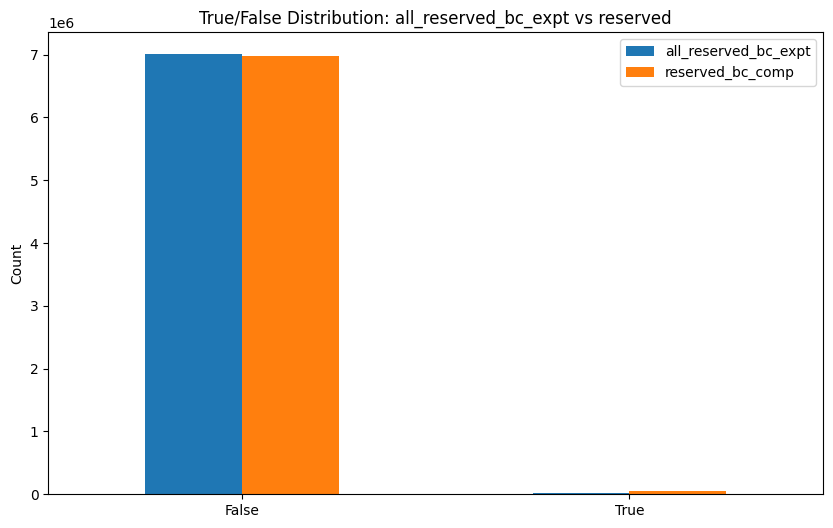

In [4]:
# Using seaborn for even simpler plotting
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Combine both columns for comparison
combined_data = pd.DataFrame(
    {
        "all_reserved_bc_expt": df["all_reserved_bc_expt"].value_counts(),
        "reserved_bc_comp": df["reserved_bc_comp"].value_counts(),
    }
).fillna(0)

combined_data.plot(kind="bar", ax=ax)
plt.title("True/False Distribution: all_reserved_bc_expt vs reserved")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [5]:
selected_df = df[df["all_reserved_bc_expt"] is True]

In [6]:
import yaml


def process_input(line):
    data_dict = yaml.safe_load(line)
    data_dict.pop("reserved_bc_comp", None)
    data_dict.pop("all_reserved_bc_expt", None)
    context_data = data_dict.pop("context")
    data_dict["context"] = list({frozenset(item.items()): item for item in context_data}.values())
    if len(data_dict["context"]) == 1:
        data_dict["context"] = data_dict["context"][0]

    return json.dumps(data_dict)


selected_df["original_inputs"] = selected_df["inputs"]
selected_df["inputs"] = selected_df["original_inputs"].apply(process_input)

/var/folders/rl/wwcfdj4x0pg293bfqszl970r0000gq/T/ipykernel_11627/684051572.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["original_inputs"] = selected_df["inputs"]
/var/folders/rl/wwcfdj4x0pg293bfqszl970r0000gq/T/ipykernel_11627/684051572.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["inputs"] = selected_df["original_inputs"].apply(process_input)


In [10]:


def extract_smiles(line):
    try:
        data_dict = yaml.safe_load(line)
    except:
        print(line)
        raise ValueError("Invalid JSON")
    smiles_list = []
    pert_data = data_dict.pop("perturbations", [])
    for x in pert_data:
        if "smiles" in x:
            smiles_list.append(x["smiles"])
    return smiles_list


selected_df["smiles"] = selected_df["inputs"].apply(extract_smiles)

/var/folders/rl/wwcfdj4x0pg293bfqszl970r0000gq/T/ipykernel_11627/2084761306.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["smiles"] = selected_df["inputs"].apply(extract_smiles)


In [11]:
annotated_mols = pd.read_parquet("../../data/curation_v1/perturbations/annotated_molecules.parquet")

In [12]:
annotated_mols

,smiles,synonym_list,inchi_key,top_name_1,top_name_2,top_name_3,reason_1,reason_2,reason_3,bioactivities,bioactivity_summary
0,BrC1=C(Br)C(Br)=C2C(=C1Br)N=NN2,"[4,5,6,7-tetrabromobenzotriazole, TBB benzotri...",OMZYUVOATZSGJY-UHFFFAOYSA-N,"4,5,6,7-tetrabromobenzotriazole",TBB,Casein Kinase II Inhibitor I,"4,5,6,7-tetrabromobenzotriazole is a well-know...",TBB is a common abbreviation used in scientifi...,Casein Kinase II Inhibitor I is a recognized n...,"{""synonym_names"":[""4,5,6,7-tetrabromobenzotria...","TBB, also known as 4,5,6,7-tetrabromobenzotria..."
1,BrC1=C(C2=NN=C(SCC(=O)NC(C3=CC=CS3)C3=CC=CC=C3...,"[AKOS001119592, Z97151845]",BJPSWVDDULSZMD-UHFFFAOYSA-N,None,None,None,None,None,None,"{""synonym_names"":[""AKOS001119592"",""Z97151845""]...",The compound with synonyms AKOS001119592 and Z...
2,BrC1=C(CN2C(=O)NC(C2=O)(C2=CC=CC=C2)C2=CC=CC=C...,"[AKOS007932363, Z14471460]",QEUFPVZFLQCQNK-UHFFFAOYSA-N,None,None,None,None,None,None,"{""synonym_names"":[""AKOS007932363"",""Z14471460""]...","The compound, known by synonyms AKOS007932363 ..."
3,BrC1=C(C[N+]2(CCOCCC3[C@H]4C(C)(C)[C@H](C4)CC3...,"[SCHEMBL9359902, CHEMBL4303628, NCGC00388506-0...",DDHUTBKXLWCZCO-GFUWAVFVSA-N,None,None,None,None,None,None,"{""synonym_names"":[""NCGC00388506-02"",""SCHEMBL93...",The compound known by the synonyms NCGC0038850...
4,BrC1=C(F)C(Br)=CC2=C1CCC(C)N2C=O,"[6-Fluoro-5,7-dibromo-2-methyl-1-formyl-1,2,3,...",ZZLQPWXVZCPUGC-UHFFFAOYSA-N,"6-Fluoro-5,7-dibromo-2-methyl-1-formyl-1,2,3,4...",CE3F4,"5,7-Dibromo-6-fluoro-2-methyl-3,4-dihydroquino...","6-Fluoro-5,7-dibromo-2-methyl-1-formyl-1,2,3,4...",CE3F4 is a common research compound code.,"5,7-Dibromo-6-fluoro-2-methyl-3,4-dihydroquino...","{""synonym_names"":[""5,7-Dibromo-6-fluoro-2-meth...","5,7-Dibromo-6-fluoro-2-methyl-3,4-dihydroquino..."
...,...,...,...,...,...,...,...,...,...,...,...
9467,c1cc(S(=O)(=O)N)ccc1N1C(c2ccc(F)cc2F)CC(C(F)(F...,"[Enflicoxib, 251442-94-1, VM9PYQ1MQG, E-6087, ...",ZZMJXWXXMAAPLI-UHFFFAOYSA-N,Enflicoxib,E-6087,Enflicoxib [INN],Enflicoxib is the common drug name.,E-6087 is a recognized research compound code.,Enflicoxib [INN] is the international nonpropr...,"{""synonym_names"":[""E-6087"",""Enflicoxib"",""Enfli...",Enflicoxib (InChIKey: ZZMJXWXXMAAPLI-UHFFFAOYS...
9468,c1cc2c(cc1C(=O)N[C@@H](CCCC(=O)O)C(=O)O)SCCN2C...,"[MX-68, NEW3SXG55F, 156579-02-1, MX 68, UNII-N...",WEEYASWRWODDTJ-ZDUSSCGKSA-N,MX-68,MX68,UNII-NEW3SXG55F,MX-68 is a recognized research compound name.,MX68 is an alternative recognized name.,UNII-NEW3SXG55F is a recognized database ident...,"{""synonym_names"":[""(2S)-2-[[4-[(2,4-diaminopte...",MX-68 (InChIKey: WEEYASWRWODDTJ-ZDUSSCGKSA-N; ...
9469,c1ccc(c2ccc(C[C@H](C(=O)N[C@H](CCCNC(=N)N)C(=O...,[AZD2479],RNXMFZGFDRHMAL-NJDAHSKKSA-N,None,None,None,None,None,None,"{""synonym_names"":[""AZD2479""],""smiles"":""c1ccc(c...",AZD2479 (InChIKey: RNXMFZGFDRHMAL-NJDAHSKKSA-N...
9470,c1cn([C@H]2/C(=C/F)[C@H](O)[C@@H](CO)O2)c(=O)nc1N,"[Tezacitabine, MDL-101731, 2'-Deoxy-2'-(fluoro...",GFFXZLZWLOBBLO-ASKVSEFXSA-N,Tezacitabine,Tezacitabine [INN],Tezacitabine monohydrate,Tezacitabine is the most commonly used name fo...,Tezacitabine [INN] indicates its recognition a...,Tezacitabine monohydrate is a specific form of...,"{""synonym_names"":[""(E)-2'-Deoxy-2'-(fluorometh...",Tezacitabine (InChIKey: GFFXZLZWLOBBLO-ASKVSEF...


In [38]:
def build_inputs(row):
    """
    Build inputs for the LLM.
    """
    pertubation = json.dumps(row["inputs"])
    annot_mols = annotated_mols[annotated_mols["smiles"].isin(row["smiles"])]
    prior_info = "\n---\n".join(annot_mols["bioactivity_summary"].tolist())
    if prior_info:
        prior_info = f"Here is what we know about some of the perturbations already.\n{prior_info}"
    return dict(prior_knowledge_if_any=prior_info, treatment=pertubation)


selected_df["prompt"] = selected_df.apply(build_inputs, axis=1)

/var/folders/rl/wwcfdj4x0pg293bfqszl970r0000gq/T/ipykernel_11627/1281161878.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["prompt"] = selected_df.apply(build_inputs, axis=1)


### Load enhanced chat

In [137]:
import time
import webbrowser

import httpx
from rxrx.enhanced_chat.client import AuthenticatedClient

BASE_URL = "https://enhanced-chat.centaur-platform-dev.com/"

OKTA_AUTH_ENDPOINT = "https://okta.recursionpharma.com:443/oauth2/aus1jtjmacbPAsg0r358/v1/device/authorize"
OKTA_TOKEN_ENDPOINT = "https://recursion.okta.com/oauth2/aus1jtjmacbPAsg0r358/v1/token"
CLIENT_ID = "0oalcb8yf53FyRD9g5d7"


# Maybe this should be included in the client library?
async def auth(base_url: str):
    # Perform device code flow with browser
    device_code_r = httpx.post(
        OKTA_AUTH_ENDPOINT,
        headers={
            "Accept": "application/json",
            "Content-Type": "application/x-www-form-urlencoded",
        },
        data={
            "client_id": CLIENT_ID,
            "scope": "openid email profile groups offline_access",
        },
    )
    device_code_response = device_code_r.json()
    device_code = device_code_response["device_code"]
    webbrowser.open(device_code_response["verification_uri_complete"])
    access_token = None
    # Poll until the browser authentication session has completed
    while access_token is None:
        token_r = httpx.post(
            OKTA_TOKEN_ENDPOINT,
            headers={
                "Accept": "application/json",
                "Content-Type": "application/x-www-form-urlencoded",
            },
            data={
                "client_id": CLIENT_ID,
                "device_code": device_code,
                "grant_type": "urn:ietf:params:oauth:grant-type:device_code",
            },
        )
        token_r_response = token_r.json()
        if token_r_response.get("error") == "authorization_pending":
            time.sleep(3)
            continue
        if token_r_response.get("access_token"):
            access_token = token_r_response.get("access_token")
    # Create client
    return AuthenticatedClient(base_url=base_url, token=access_token, raise_on_unexpected_status=True)

In [140]:

access_token = await auth(BASE_URL)

Build the enhanced chat client for launching jobs

In [85]:
from rxrx.enhanced_chat.api.bulk_controller_v1 import (
    bulk_controller_v1_create,
)
from rxrx.enhanced_chat.models.bulk_conversation_input import BulkConversationInput
from rxrx.enhanced_chat.models.model import Model
from rxrx.enhanced_chat.models.output_style import OutputStyle

from explain.enhanced_chat.manager import EnhancedChatManager

client = AuthenticatedClient(base_url="https://enhanced-chat.centaur-platform-dev.com/", token=access_token)
chat_manager = EnhancedChatManager(client)
chat_manager.update_config(
    model=Model.CLAUDE_V3_7_SONNET,
    kg_rag_enabled=True,
    omim_enabled=True,
    pubmed_enabled=True,
    fulltext_enabled=True,
    citeline_enabled=True,
    kg_agent_enabled=True,
    max_pubmed_to_read=15,
    max_fulltext_to_read=5,
    max_pdf_index_to_read=5,
    max_citeline_to_read=5,
    max_google_to_read=5,
    max_preprint_to_read=0,
    output_style=OutputStyle.NATURE,
    is_shareable=True,
)

In [105]:
import json


def batch(iterable, n: int = 1):
    length = len(iterable)
    for ndx in range(0, length, n):
        yield iterable[ndx : min(ndx + n, length)]

In [115]:
N = 10
batch_size = 5
global_tags = ["hooke-explain", "case-study", "perturbation", "v2"]

In [116]:
from datetime import datetime

report_template = open(os.path.join(DATA_DIR, "templates/auto-report.txt")).read()
job_tag = "hooke-explain-eval-{}-{}".format(datetime.now().strftime("%Y%m%d%H%M"), N)
print(job_tag)

# Now run the efficient processing
treatments = selected_df.sort_values(
    by="prompt", key=lambda x: x.apply(lambda x: len(x.get("prior_knowledge_if_any", ""))), ascending=True
)
treatments = treatments["prompt"].tolist()


prompts = chat_manager.create_prompts(
    template=report_template,
    data=treatments[:N],
    global_tags=[job_tag] + global_tags,
)

hooke-explain-eval-202508130947-10


In [117]:
len(prompts)

10

In [ ]:
prompt_batches = list(batch(prompts, n=batch_size))

client = AuthenticatedClient(base_url="https://enhanced-chat.centaur-platform-dev.com/", token=access_token)
created_by_batch = {}
client = await client.__aenter__()
for batch_idx, batch_prompts in enumerate(prompt_batches):
    batch_tag = f"{job_tag}-batch-{batch_idx:04d}"
    body = BulkConversationInput(
        prompts=batch_prompts,
        model=Model.CLAUDE_V3_7_SONNET,
        google_enabled=True,
        pdf_index_enabled=True,
        kg_rag_enabled=True,
        omim_enabled=True,
        pubmed_enabled=True,
        fulltext_enabled=True,
        citeline_enabled=True,
        kg_agent_enabled=True,
        max_pubmed_to_read=15,
        max_fulltext_to_read=5,
        max_pdf_index_to_read=5,
        max_citeline_to_read=5,
        max_google_to_read=5,
        max_preprint_to_read=0,
        preprint_enabled=False,
        output_style=OutputStyle.NATURE,
        is_shareable=True,
        max_brave_to_read=0,
        max_ci_agent_to_read=0,
        brave_enabled=False,
        cov_enabled=False,
        is_private=False,
        tags=[job_tag, batch_tag],
        do_repeats=False,
    )
    created = await bulk_controller_v1_create.asyncio(client=client, body=body)
    created_by_batch[batch_idx] = created

In [119]:
created_by_batch

{0: None, 1: None}